In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abiolaoolaleye/computer-vision/images.npy
/kaggle/input/datasets/abiolaoolaleye/computer-vision/Labels.csv


# Load datasets

In [2]:
import os
import numpy as np
import pandas as pd

INPUT_DIR = "/kaggle/input/datasets/abiolaoolaleye/computer-vision"

images_path = os.path.join(INPUT_DIR, "images.npy")
labels_path = os.path.join(INPUT_DIR, "Labels.csv")

images = np.load(images_path)
labels_df = pd.read_csv(labels_path)

print("Images shape:", images.shape)
print("Labels shape:", labels_df.shape)

Images shape: (4750, 128, 128, 3)
Labels shape: (4750, 1)


# Encode labels

In [3]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels_df["Label"])

num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes=num_classes)

print("num_classes:", num_classes)

2026-04-02 14:06:32.534883: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775138792.787301      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775138792.861976      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775138793.465552      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775138793.465595      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775138793.465598      24 computation_placer.cc:177] computation placer alr

num_classes: 12


# Split datasets

In [4]:
from sklearn.model_selection import train_test_split
import numpy as np

SEED = 42

X_train, X_temp, y_train, y_temp = train_test_split(
    images,
    y_cat,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

y_temp_labels = np.argmax(y_temp, axis=1)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp_labels
)

# Define num_classes

In [5]:
num_classes = y_train.shape[1]

# Build model

In [6]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

IMG_SIZE = 224

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)

# ✅ FIX HERE
outputs = layers.Dense(num_classes, activation="softmax")(x)

efficient_model = models.Model(inputs, outputs)

efficient_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model ready with", num_classes, "classes")

I0000 00:00:1775138820.016177      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model ready with 12 classes


# Train model

In [7]:
# 1. Reload data
import os
import numpy as np
import pandas as pd

INPUT_DIR = "/kaggle/input/datasets/abiolaoolaleye/computer-vision"

images = np.load(os.path.join(INPUT_DIR, "images.npy"))
labels_df = pd.read_csv(os.path.join(INPUT_DIR, "Labels.csv"))

print(images.shape, labels_df.shape)

(4750, 128, 128, 3) (4750, 1)


In [8]:
# Encode labels
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels_df["Label"])

num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes=num_classes)

print("num_classes:", num_classes)
print("y_cat shape:", y_cat.shape)

num_classes: 12
y_cat shape: (4750, 12)


In [9]:
# Split data
from sklearn.model_selection import train_test_split

SEED = 42

X_train, X_temp, y_train, y_temp, y_train_labels, y_temp_labels = train_test_split(
    images,
    y_cat,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp_labels
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (3800, 128, 128, 3) (3800, 12)
Val: (475, 128, 128, 3) (475, 12)
Test: (475, 128, 128, 3) (475, 12)


In [10]:
# Create X_train_eff, X_val_eff, X_test_eff
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224

def preprocess_images(X):
    X = tf.convert_to_tensor(X, dtype=tf.float32)
    X = tf.image.resize(X, (IMG_SIZE, IMG_SIZE))
    X = preprocess_input(X)
    return X.numpy()

X_train_eff = preprocess_images(X_train)
X_val_eff = preprocess_images(X_val)
X_test_eff = preprocess_images(X_test)

print("X_train_eff:", X_train_eff.shape)
print("X_val_eff:", X_val_eff.shape)
print("X_test_eff:", X_test_eff.shape)

X_train_eff: (3800, 224, 224, 3)
X_val_eff: (475, 224, 224, 3)
X_test_eff: (475, 224, 224, 3)


In [11]:
import os

print(os.listdir("/kaggle/input/datasets"))

['abiolaoolaleye']


In [12]:
import os
print(os.listdir("/kaggle/input/datasets/abiolaoolaleye"))

['computer-vision']


In [13]:
import os
import numpy as np
import pandas as pd

BASE_PATH = "/kaggle/input/datasets/abiolaoolaleye"

print("Level 2 contents:", os.listdir(BASE_PATH))

def find_file(base_path, filename):
    for root, dirs, files in os.walk(base_path):
        if filename in files:
            return os.path.join(root, filename)
    return None

images_path = find_file(BASE_PATH, "images.npy")
labels_path = find_file(BASE_PATH, "Labels.csv")

print("Images path:", images_path)
print("Labels path:", labels_path)

if images_path is None or labels_path is None:
    raise FileNotFoundError(
        f"Could not find images.npy and Labels.csv under {BASE_PATH}"
    )

images = np.load(images_path)
labels_df = pd.read_csv(labels_path)

print("Loaded successfully")
print("Images shape:", images.shape)
print("Labels shape:", labels_df.shape)
print(labels_df.head())

Level 2 contents: ['computer-vision']
Images path: /kaggle/input/datasets/abiolaoolaleye/computer-vision/images.npy
Labels path: /kaggle/input/datasets/abiolaoolaleye/computer-vision/Labels.csv
Loaded successfully
Images shape: (4750, 128, 128, 3)
Labels shape: (4750, 1)
                       Label
0  Small-flowered Cranesbill
1  Small-flowered Cranesbill
2  Small-flowered Cranesbill
3  Small-flowered Cranesbill
4  Small-flowered Cranesbill


In [14]:
# Encode labels

import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels_df["Label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

y_cat = to_categorical(y, num_classes=num_classes)

print("Number of classes:", num_classes)
print("Classes:", class_names)
print("Encoded labels shape:", y_cat.shape)

Number of classes: 12
Classes: ['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed', 'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize', 'Scentless Mayweed', 'Shepherds Purse', 'Small-flowered Cranesbill', 'Sugar beet']
Encoded labels shape: (4750, 12)


In [15]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels_df["Label"])

# One-hot encoding
num_classes = len(np.unique(y))
y_cat = to_categorical(y, num_classes=num_classes)

print("num_classes:", num_classes)
print("y_cat shape:", y_cat.shape)

num_classes: 12
y_cat shape: (4750, 12)


In [16]:
num_classes = y_cat.shape[1]
print("num_classes:", num_classes)

num_classes: 12


In [17]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [18]:
#Rebuild the model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

IMG_SIZE = 224

num_classes = y_train.shape[1]

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

efficient_model = models.Model(inputs, outputs)

efficient_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

efficient_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 12)             │         3,084 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,711 (16.73 MB)

 Trainable params: 333,580 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [19]:
# Train EfficientNet
history_stage1 = efficient_model.fit(
    X_train_eff,
    y_train,
    validation_data=(X_val_eff, y_val),
    epochs=15,
    batch_size=32
)

Epoch 1/15


I0000 00:00:1775138847.609415      70 service.cc:152] XLA service 0x7f2f78003f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775138847.609453      70 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775138850.221575      70 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775138863.341774      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


119/119 ━━━━━━━━━━━━━━━━━━━━ 62s 288ms/step - accuracy: 0.4765 - loss: 1.7911 - val_accuracy: 0.8189 - val_loss: 0.8178
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.7723 - loss: 0.6624 - val_accuracy: 0.8526 - val_loss: 0.5098
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8030 - loss: 0.5507 - val_accuracy: 0.8526 - val_loss: 0.4610
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8365 - loss: 0.4750 - val_accuracy: 0.8632 - val_loss: 0.3941
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8569 - loss: 0.4089 - val_accuracy: 0.8884 - val_loss: 0.3773
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8857 - loss: 0.3452 - val_accuracy: 0.8863 - val_loss: 0.3665
Epoch 7/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.8947 - loss: 0.3014 - val_accuracy: 0.8842 - val_loss: 0.3592
Epoch 8/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9013 - loss: 0.2637 - val_accuracy: 0.8

In [20]:
#Evaluate on the test set
test_loss, test_acc = efficient_model.evaluate(X_test_eff, y_test, verbose=1)
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9024 - loss: 0.3626
Test loss: 0.3396
Test accuracy: 0.9074


In [21]:
#Generate classification report
from sklearn.metrics import classification_report
import numpy as np

y_pred_probs = efficient_model.predict(X_test_eff, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))

                           precision    recall  f1-score   support

              Black-grass       0.65      0.65      0.65        26
                 Charlock       0.91      1.00      0.95        39
                 Cleavers       0.94      1.00      0.97        29
         Common Chickweed       0.98      0.98      0.98        61
             Common wheat       1.00      0.82      0.90        22
                  Fat Hen       0.90      0.96      0.93        47
         Loose Silky-bent       0.83      0.91      0.87        66
                    Maize       0.95      0.91      0.93        22
        Scentless Mayweed       0.89      0.96      0.93        52
          Shepherds Purse       0.93      0.57      0.70        23
Small-flowered Cranesbill       0.94      0.94      0.94        50
               Sugar beet       1.00      0.87      0.93        38

                 accuracy                           0.91       475
                macro avg       0.91      0.88      0.89    

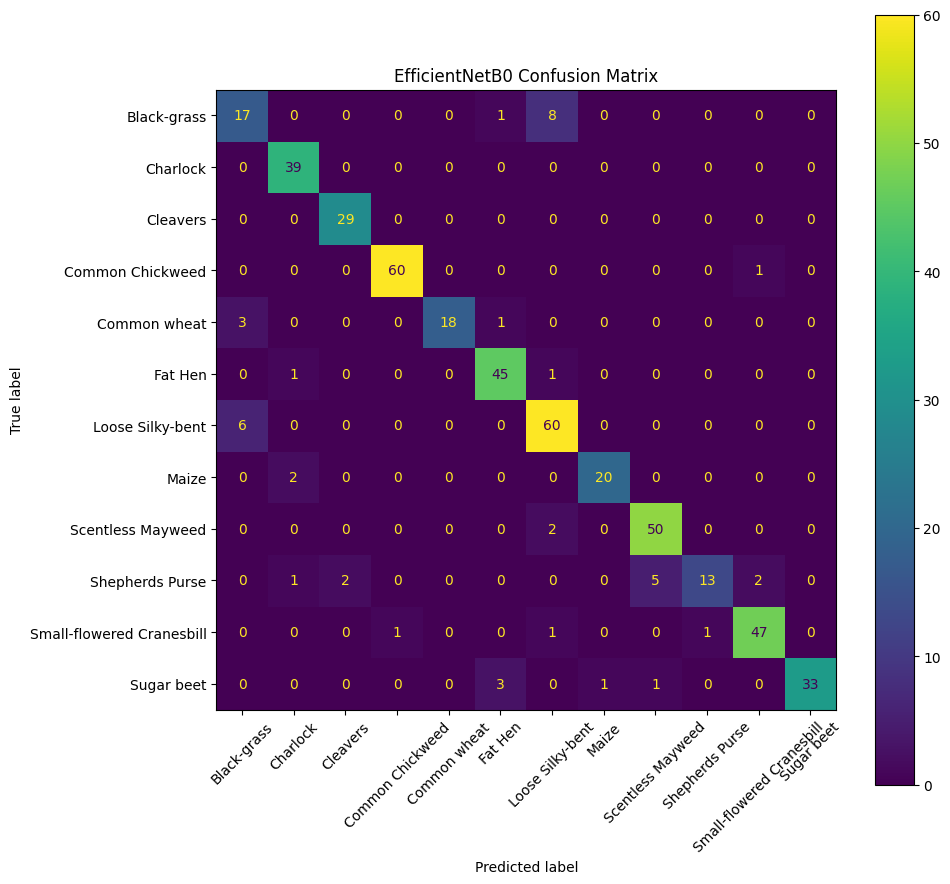

In [22]:
# Plot the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

# Callbacks again

In [23]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),
    ModelCheckpoint(
        "best_efficientnet_b0.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

# Rerun fine-tuning

In [24]:
history_stage2 = efficient_model.fit(
    X_train_eff,
    y_train,
    validation_data=(X_val_eff, y_val),
    epochs=10,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9277 - loss: 0.1967 - val_accuracy: 0.8821 - val_loss: 0.3818 - learning_rate: 0.0010
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9178 - loss: 0.2053 - val_accuracy: 0.9074 - val_loss: 0.3524 - learning_rate: 0.0010
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9296 - loss: 0.1970 - val_accuracy: 0.8989 - val_loss: 0.3771 - learning_rate: 0.0010
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9349 - loss: 0.1900 - val_accuracy: 0.9011 - val_loss: 0.3753 - learning_rate: 0.0010
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9401 - loss: 0.1783 - val_accuracy: 0.9074 - val_loss: 0.3343 - learning_rate: 2.0000e-04
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9567 - loss: 0.1310 - val_accuracy: 0.9032 - val_loss: 0.3433 - learning_rate: 2.0000e-04
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9614 - 

In [25]:
for layer in base_model.layers[:-10]:
    layer.trainable = False

In [26]:
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

efficient_model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
best_model = tf.keras.models.load_model("best_efficientnet_b0.keras")

In [28]:
test_loss, test_acc = best_model.evaluate(X_test_eff, y_test)
print("Test accuracy:", test_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 372ms/step - accuracy: 0.9111 - loss: 0.3065
Test accuracy: 0.9073684215545654


Fine-tuning was attempted to improve performance by unfreezing upper EfficientNet layers. However, validation accuracy decreased, indicating overfitting and instability due to excessive parameter updates on a relatively small dataset. The best-performing model was therefore selected from the transfer learning stage, demonstrating that pretrained features were already sufficient for this task.

# Load best model (Stage 1)

In [29]:
import tensorflow as tf

best_model = tf.keras.models.load_model("best_efficientnet_b0.keras")

print("✅ Best model loaded")

✅ Best model loaded


# Final evaluation (TEST set)

In [30]:
test_loss, test_acc = best_model.evaluate(X_test_eff, y_test, verbose=1)

print("Final Test Loss:", round(test_loss, 4))
print("Final Test Accuracy:", round(test_acc, 4))

15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 380ms/step - accuracy: 0.9111 - loss: 0.3065
Final Test Loss: 0.322
Final Test Accuracy: 0.9074


# Classification report and confusion matrix

# Predictions

In [31]:
import numpy as np

y_pred_probs = best_model.predict(X_test_eff, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification report

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                           precision    recall  f1-score   support

              Black-grass       0.75      0.69      0.72        26
                 Charlock       0.93      0.97      0.95        39
                 Cleavers       0.97      1.00      0.98        29
         Common Chickweed       0.98      0.97      0.98        61
             Common wheat       0.95      0.82      0.88        22
                  Fat Hen       0.92      0.94      0.93        47
         Loose Silky-bent       0.81      0.92      0.87        66
                    Maize       0.95      0.86      0.90        22
        Scentless Mayweed       0.88      0.96      0.92        52
          Shepherds Purse       0.87      0.57      0.68        23
Small-flowered Cranesbill       0.92      0.96      0.94        50
               Sugar beet       1.00      0.89      0.94        38

                 accuracy                           0.91       475
                macro avg       0.91      0.88      0.89    

# Confusion matrix

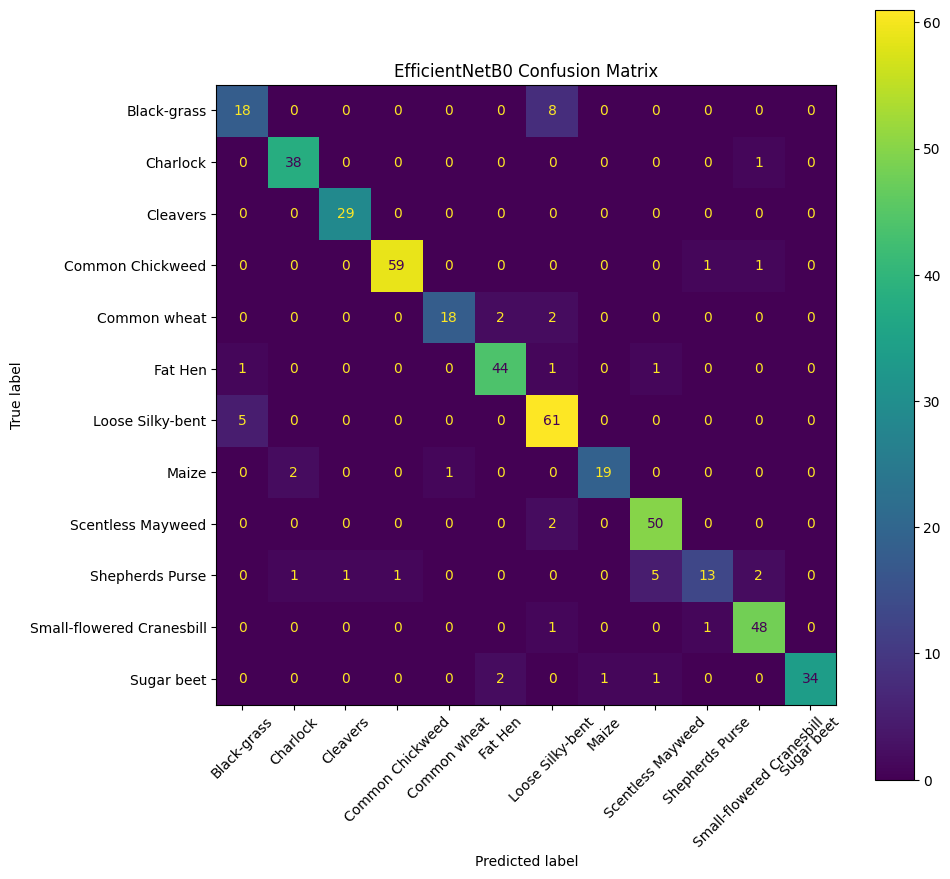

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

## Conclusion

This project demonstrated the effectiveness of transfer learning using EfficientNetB0 for plant seedling classification. The pretrained model achieved high validation and test accuracy with minimal training, highlighting the strength of learned image representations.

Fine-tuning was also explored by unfreezing upper layers of the network. However, performance decreased slightly, indicating overfitting due to the relatively small dataset size. As a result, the best-performing model from the transfer learning stage was selected.

This approach shows that, for moderately sized datasets, pretrained convolutional networks can deliver strong performance without extensive fine-tuning.

## Key Insights

- Transfer learning provided strong baseline performance (~90% accuracy)
- Fine-tuning must be carefully controlled to avoid overfitting
- EfficientNetB0 is highly effective for small-to-medium image datasets
- Model evaluation using confusion matrix revealed class-level performance differences